In [2]:
import pandas as pd
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Zip dosyasını çıkarma fonksiyonu
def extract_zip(zip_path, extract_to):
    # Eğer çıkarılacak klasör yoksa oluştur
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    
    # Zip dosyasını kontrol et ve çıkar
    if os.path.exists(zip_path):
        print(f"Zip dosyası çıkarılıyor: {zip_path}")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"Dosyalar şuraya çıkarıldı: {extract_to}")
    else:
        print(f"HATA: Zip dosyası bulunamadı: {zip_path}")

# Dosya yolları
zip_path = r"C:\Users\Sercan ARABACI\Desktop\Projects\Can_thesis_NLP\crypto_posts-002.zip"
extract_to = r"C:\Users\Sercan ARABACI\Desktop\Projects\Can_thesis_NLP\extracted_files"
file_path = os.path.join(extract_to, "crypto_posts-002.csv")

# Zip dosyasını çıkar
extract_zip(zip_path, extract_to)

# Veri seti hakkında temel tarih analizi
print("Dosya okunuyor ve tarih analizi yapılıyor...")

# Başlangıç değerleri
min_date = pd.Timestamp.max
max_date = pd.Timestamp.min

# Toplam satır sayısını takip etmek için
total_rows = 0

# CSV dosyasını parçalar halinde okuma
chunk_size = 100000  # Bellek kapasitesine göre ayarlayabilirsiniz
try:
    for chunk_num, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
        # İlerleme durumunu yazdırma
        if chunk_num % 10 == 0:
            print(f"Parça {chunk_num} işleniyor...")

        # 'created_at' sütununu datetime formatına dönüştürme
        chunk['created_at'] = pd.to_datetime(chunk['created_at'])

        # Satır sayısını güncelleme
        total_rows += len(chunk)

        # Bu parçadaki minimum ve maksimum tarihleri bulma
        chunk_min_date = chunk['created_at'].min()
        chunk_max_date = chunk['created_at'].max()

        # Genel minimum ve maksimum tarihleri güncelleme
        if chunk_min_date < min_date:
            min_date = chunk_min_date

        if chunk_max_date > max_date:
            max_date = chunk_max_date

    # Bulunan minimum ve maksimum tarihleri yazdırma
    print("\n===== TARİH ANALİZİ =====")
    print(f"Toplam kayıt sayısı: {total_rows}")
    print(f"Veri setindeki en erken tarih: {min_date}")
    print(f"Veri setindeki en son tarih: {max_date}")

    # Tarih aralığını hesaplama
    date_range = max_date - min_date
    print(f"Toplam tarih aralığı: {date_range.days} gün")

    # Yıl analizi
    print("\n===== YIL DAĞILIMI ANALİZİ =====")
    year_counts = {}

    # CSV dosyasını tekrar parçalar halinde okuma
    for chunk_num, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
        if chunk_num % 10 == 0:
            print(f"Yıl analizinde parça {chunk_num} işleniyor...")

        # 'created_at' sütununu datetime formatına dönüştürme
        chunk['created_at'] = pd.to_datetime(chunk['created_at'])

        # Bu parçadaki yılları sayma
        years = chunk['created_at'].dt.year.value_counts().to_dict()

        # Genel yıl sayılarını güncelleme
        for year, count in years.items():
            if year in year_counts:
                year_counts[year] += count
            else:
                year_counts[year] = count

    # Yılları yazdırma
    print("\nVeri setindeki yıl dağılımı:")
    for year in sorted(year_counts.keys()):
        print(f"{year}: {year_counts[year]} kayıt ({(year_counts[year]/total_rows*100):.2f}%)")

except Exception as e:
    print(f"Bir hata oluştu: {e}")

# Veri seti kolon yapısını inceleme
try:
    # Sadece başlık satırını okumak için nrows=0 kullanıyoruz
    # Bu şekilde hiç veri okumadan sadece kolon isimlerini alıyoruz
    headers = pd.read_csv(file_path, nrows=0)

    # Kolon isimlerini alalım
    column_names = headers.columns.tolist()

    # Kolon sayısını hesaplayalım
    num_columns = len(column_names)

    print(f"Toplam kolon sayısı: {num_columns}")
    print("\nKolon isimleri:")

    # Kolon isimlerini ve veri tiplerini yazdıralım
    for i, column in enumerate(column_names, 1):
        print(f"{i}. {column}")

    # Veri tiplerini görmek için ilk birkaç satırı okutalım
    print("\nKolon veri tipleri:")

    # İlk 5 satırı okuyup veri tiplerini kontrol edelim
    sample_data = pd.read_csv(file_path, nrows=5)
    print(sample_data.dtypes)

    # İlk birkaç satırı gösterelim (opsiyonel)
    print("\nVeri setinden örnek satırlar:")
    print(sample_data.head())

except Exception as e:
    print(f"Bir hata oluştu: {e}")

# İlgilendiğimiz tarih aralığı (2021-05-01 - 2023-06-30 arası veriyi filtreleme)
start_date = '2021-05-01'
end_date = '2023-06-30'

# İlgilendiğimiz sütunlar
# Temel NLP analizi için gerekli sütunları seçiyoruz
columns_of_interest = [
    'source',             # Verinin kaynağı (twitter, reddit, vb.)
    'source_id',          # Özgün kaynak ID'si
    'created_at',         # Oluşturulma tarihi (filtreleme için)
    'text',               # NLP için ana metin içeriği
    'asset_codes',        # Hangi kripto varlıklarından bahsediliyor
    'username',           # Kullanıcı adı (ağ analizi için)
    'comments',           # Etkileşim metrikleri
    'likes',              # Etkileşim metrikleri
    'topic',              # Konu kategorizasyonu
    'group'               # Grup kategorizasyonu
]

# Parçalar halinde CSV dosyasını okuma ve filtreleme
chunks = []
chunk_size = 100000

print("Veri okuma ve filtreleme başlıyor...")

filtered_output_path = os.path.join(extract_to, 'filtered_crypto_data.csv')

try:
    for chunk_num, chunk in enumerate(pd.read_csv(file_path, usecols=columns_of_interest, chunksize=chunk_size)):
        if chunk_num % 10 == 0:
            print(f"Parça {chunk_num} işleniyor...")

        # 'created_at' sütununu datetime formatına dönüştürme
        chunk['created_at'] = pd.to_datetime(chunk['created_at'])

        # Tarih aralığına göre filtreleme
        filtered_chunk = chunk[(chunk['created_at'] >= start_date) & (chunk['created_at'] <= end_date)]

        # Filtrelenmiş veri parçasını listeye ekleme
        if not filtered_chunk.empty:
            chunks.append(filtered_chunk)

    # Tüm filtrelenmiş parçaları birleştirme
    if chunks:
        filtered_data = pd.concat(chunks, ignore_index=True)

        # Sonuçları gösterme
        print("\n===== FİLTRELENMİŞ VERİ İSTATİSTİKLERİ =====")
        print(f"Toplam kayıt sayısı: {len(filtered_data)}")
        print(f"Tarih aralığı: {filtered_data['created_at'].min()} - {filtered_data['created_at'].max()}")

        # Kaynak dağılımı
        source_counts = filtered_data['source'].value_counts()
        print("\nKaynak dağılımı:")
        print(source_counts)

        # Aylık kayıt sayısı
        filtered_data['month_year'] = filtered_data['created_at'].dt.to_period('M')
        monthly_counts = filtered_data['month_year'].value_counts().sort_index()
        print("\nAylık kayıt sayısı:")
        print(monthly_counts)

        # Örnek kayıtlar
        print("\nÖrnek kayıtlar (ilk 5):")
        print(filtered_data.head())

        # Veriyi kaydetme
        filtered_data.to_csv(filtered_output_path, index=False)
        print(f"\nFiltrelenmiş veri şu konuma kaydedildi: {filtered_output_path}")

    else:
        print("Belirtilen tarih aralığında veri bulunamadı.")

except Exception as e:
    print(f"Bir hata oluştu: {e}")

# Filtrelenmiş veri setini yükleme

try:
    # Veriyi okuma
    print("Veri yükleniyor...")
    df = pd.read_csv(filtered_output_path)

    # 'created_at' sütununu datetime formatına dönüştürme
    print("Tarih sütunu dönüştürülüyor...")
    df['created_at'] = pd.to_datetime(df['created_at'])

    # Veriyi 'created_at' sütununa göre sıralama (eskiden yeniye doğru)
    print("Veri tarihe göre sıralanıyor...")
    df_sorted = df.sort_values(by='created_at')

    # Sıralanmış veriyi kaydetme
    sorted_output_path = os.path.join(extract_to, 'sorted_crypto_data.csv')
    df_sorted.to_csv(sorted_output_path, index=False)
    print(f"Sıralanmış veri şu konuma kaydedildi: {sorted_output_path}")

    # Tarih aralığını kontrol etme
    print("\n===== SIRALANMIŞ VERİ BİLGİLERİ =====")
    print(f"Toplam kayıt sayısı: {len(df_sorted)}")
    print(f"Tarih aralığı: {df_sorted['created_at'].min()} - {df_sorted['created_at'].max()}")

    # İlk ve son kayıtları gösterme
    print("\nEn eski 5 kayıt:")
    print(df_sorted.head()[['created_at', 'source', 'text', 'asset_codes']])

    print("\nEn yeni 5 kayıt:")
    print(df_sorted.tail()[['created_at', 'source', 'text', 'asset_codes']])

    # Örnekleme yaparak verilerin dağılımını kontrol etme
    print("\nFarklı dönemlerdeki örnek kayıtlar:")

    # Veri setini 5 eşit parçaya bölme ve her bir parçanın ortasından bir örnek gösterme
    indices = [int(len(df_sorted) * i / 5) for i in range(5)]
    for i, idx in enumerate(indices):
        print(f"\nDönem {i+1} örneği (yaklaşık tarih: {df_sorted.iloc[idx]['created_at'].strftime('%Y-%m-%d')}):")
        print(df_sorted.iloc[idx][['created_at', 'source', 'text', 'asset_codes']])

    # Aylık istatistikler
    print("\nAylık kayıt sayısı (sıralanmış):")
    df_sorted['month_year'] = df_sorted['created_at'].dt.to_period('M')
    monthly_counts = df_sorted['month_year'].value_counts().sort_index()
    print(monthly_counts)

    # Haftalık ve saatlik dağılım analizleri için ek sütunlar
    df_sorted['hour'] = df_sorted['created_at'].dt.hour
    df_sorted['weekday'] = df_sorted['created_at'].dt.dayofweek
    
    # Saatlik dağılım
    hourly_dist = df_sorted['hour'].value_counts().sort_index()
    print("\nSaatlik paylaşım dağılımı:")
    print(hourly_dist)

    # Hafta içi / hafta sonu dağılımı
    weekday_names = {0:'Pazartesi', 1:'Salı', 2:'Çarşamba', 3:'Perşembe',
                    4:'Cuma', 5:'Cumartesi', 6:'Pazar'}
    weekday_dist = df_sorted['weekday'].map(weekday_names).value_counts()
    print("\nHafta içi/hafta sonu dağılımı:")
    print(weekday_dist)

    # Metin uzunluğu analizi
    df_sorted['text_length'] = df_sorted['text'].apply(lambda x: len(str(x)))
    print("\nMetin uzunluğu istatistikleri:")
    print(df_sorted['text_length'].describe())

    # Varlık kodları analizi
    asset_counts = {}
    for assets in df_sorted['asset_codes'].dropna():
        if isinstance(assets, str):  # Null olmayan ve string olan değerleri kontrol et
            for asset in assets.split(';'):
                asset_counts[asset] = asset_counts.get(asset, 0) + 1

    # En çok bahsedilen 10 varlık
    top_assets = sorted(asset_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nEn çok bahsedilen 10 varlık:")
    for asset, count in top_assets:
        print(f"{asset}: {count}")

    # Kaynak dağılımı analizi
    source_counts = df_sorted['source'].value_counts()
    print("\nKaynak dağılımı:")
    print(source_counts)

    # Yüzdelik olarak kaynak dağılımı
    source_percentage = (source_counts / len(df_sorted) * 100).round(2)
    print("\nKaynak dağılımı (%):")
    print(source_percentage)

    # Her kaynağın ortalama metin uzunluğu
    source_text_length = df_sorted.groupby('source')['text_length'].mean().round(1).sort_values(ascending=False)
    print("\nKaynaklara göre ortalama metin uzunluğu:")
    print(source_text_length)

    # Sadece Twitter ve Reddit kaynaklarını tut
    major_sources = ['twitter', 'reddit']
    df_filtered = df_sorted[df_sorted['source'].isin(major_sources)].copy()

    print(f"Filtreleme öncesi veri sayısı: {len(df_sorted)}")
    print(f"Filtreleme sonrası veri sayısı: {len(df_filtered)}")

    # NLP projesi için gerekli sütunları seç, daha az önemli olanları çıkart
    essential_columns = ['source', 'created_at', 'text', 'hour', 'weekday', 'likes', 'comments', 'text_length']
    df_nlp = df_filtered[essential_columns].copy()

    print("NLP analizi için kullanılacak sütunlar:", df_nlp.columns.tolist())
    print(f"Veri seti boyutu: {len(df_nlp)} satır, {len(df_nlp.columns)} sütun")
    
    # NLP veri setini kaydet
    nlp_output_path = os.path.join(extract_to, 'nlp_crypto_data.csv')
    df_nlp.to_csv(nlp_output_path, index=False)
    print(f"NLP analizi için hazırlanmış veri seti şu konuma kaydedildi: {nlp_output_path}")

except Exception as e:
    print(f"Bir hata oluştu: {e}")

# Belleği temizlemek için
import gc
# Kullanmadığımız değişkenleri temizle
if 'df' in locals():
    del df
if 'filtered_data' in locals():
    del filtered_data
gc.collect()

print("\nVeri ön işleme ve analizi tamamlandı!")

Zip dosyası çıkarılıyor: C:\Users\Sercan ARABACI\Desktop\Projects\Can_thesis_NLP\crypto_posts-002.zip
Dosyalar şuraya çıkarıldı: C:\Users\Sercan ARABACI\Desktop\Projects\Can_thesis_NLP\extracted_files
Dosya okunuyor ve tarih analizi yapılıyor...
Parça 0 işleniyor...


C:\Users\Sercan ARABACI\AppData\Local\Temp\ipykernel_6656\2051990340.py:45: DtypeWarning: Columns (1,6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
C:\Users\Sercan ARABACI\AppData\Local\Temp\ipykernel_6656\2051990340.py:45: DtypeWarning: Columns (1,6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):


Parça 10 işleniyor...


C:\Users\Sercan ARABACI\AppData\Local\Temp\ipykernel_6656\2051990340.py:45: DtypeWarning: Columns (1,6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):


Parça 20 işleniyor...
Parça 30 işleniyor...
Parça 40 işleniyor...
Parça 50 işleniyor...
Parça 60 işleniyor...
Parça 70 işleniyor...
Parça 80 işleniyor...


...

Parça 90 işleniyor...


C:\Users\Sercan ARABACI\AppData\Local\Temp\ipykernel_6656\2051990340.py:168: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, chunk in enumerate(pd.read_csv(file_path, usecols=columns_of_interest, chunksize=chunk_size)):
C:\Users\Sercan ARABACI\AppData\Local\Temp\ipykernel_6656\2051990340.py:168: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, chunk in enumerate(pd.read_csv(file_path, usecols=columns_of_interest, chunksize=chunk_size)):


Parça 100 işleniyor...

===== FİLTRELENMİŞ VERİ İSTATİSTİKLERİ =====
Toplam kayıt sayısı: 6806318
Tarih aralığı: 2021-05-01 00:00:11 - 2023-06-29 23:59:46

Kaynak dağılımı:
source
twitter          6470970
reddit            333334
ptt                 1865
seeking_alpha        143
linkedin               6
Name: count, dtype: int64

Aylık kayıt sayısı:
month_year
2021-05     66417
2021-06     34375
2021-07     29973
2021-08     24384
2021-09     23933
2021-10     27671
2021-11     24721
2021-12     23058
2022-01     32126
2022-02     25179
2022-03     22517
2022-04     21026
2022-05     21893
2022-06     21127
2022-07     19856
2022-08    865838
2022-09    779607
2022-10    756088
2022-11    665540
2022-12    493177
2023-01    619679
2023-02    558245
2023-03    735586
2023-04    476550
2023-05    252699
2023-06    185053
Freq: M, Name: count, dtype: int64

Örnek kayıtlar (ilk 5):
    source            source_id          created_at  \
0  twitter  1557689253257220096 2022-08-11 11:23:53   

C:\Users\Sercan ARABACI\AppData\Local\Temp\ipykernel_6656\2051990340.py:221: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filtered_output_path)


Tarih sütunu dönüştürülüyor...
Veri tarihe göre sıralanıyor...
Sıralanmış veri şu konuma kaydedildi: C:\Users\Sercan ARABACI\Desktop\Projects\Can_thesis_NLP\extracted_files\sorted_crypto_data.csv

===== SIRALANMIŞ VERİ BİLGİLERİ =====
Toplam kayıt sayısı: 6806318
Tarih aralığı: 2021-05-01 00:00:11 - 2023-06-29 23:59:46

En eski 5 kayıt:
                 created_at   source  \
3999523 2021-05-01 00:00:11   reddit   
4185771 2021-05-01 00:00:13   reddit   
3999524 2021-05-01 00:00:34   reddit   
6796405 2021-05-01 00:00:43  twitter   
6697715 2021-05-01 00:01:04  twitter   

                                                      text asset_codes  
3999523  Woot!!! So proud of you guys. Keeps buying and...        DOGE  
4185771  9k is awesome, 20 doge is awesome any doge is ...        DOGE  
3999524  SO, FELLOW HODLERS.. my average was $0.44 and ...        DOGE  
6796405  For $AGI #EMA 12 crosses above #EMA 26 24HR Pr...        AGIX  
6697715  2 key Ethereum price metrics prove pro traders

In [3]:
# Gerekli kütüphaneleri içe aktarma
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK kütüphanelerini içe aktarma
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# NLTK için gerekli veri setlerini indirme
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Dosya yolu tanımlama
extract_to = r"C:\Users\Sercan ARABACI\Desktop\Projects\Can_thesis_NLP\extracted_files"
nlp_data_path = os.path.join(extract_to, 'nlp_crypto_data.csv')

# NLP veri setini yükleme
print("NLP veri seti yükleniyor...")
df_nlp = pd.read_csv(nlp_data_path)

# Tarih sütununu datetime formatına dönüştürme
df_nlp['created_at'] = pd.to_datetime(df_nlp['created_at'])

# Veri setinin boyutunu ve ilk birkaç satırını kontrol etme
print(f"Veri seti boyutu: {df_nlp.shape}")
print("\nİlk 5 satır:")
print(df_nlp.head())

[nltk_data] Downloading package punkt to C:\Users\Sercan
[nltk_data]     ARABACI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Sercan
[nltk_data]     ARABACI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Sercan
[nltk_data]     ARABACI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


NLP veri seti yükleniyor...
Veri seti boyutu: (6804304, 8)

İlk 5 satır:
    source          created_at  \
0   reddit 2021-05-01 00:00:11   
1   reddit 2021-05-01 00:00:13   
2   reddit 2021-05-01 00:00:34   
3  twitter 2021-05-01 00:00:43   
4  twitter 2021-05-01 00:01:04   

                                                text  hour  weekday  likes  \
0  Woot!!! So proud of you guys. Keeps buying and...     0        5     27   
1  9k is awesome, 20 doge is awesome any doge is ...     0        5      5   
2  SO, FELLOW HODLERS.. my average was $0.44 and ...     0        5     13   
3  For $AGI #EMA 12 crosses above #EMA 26 24HR Pr...     0        5      0   
4  2 key Ethereum price metrics prove pro traders...     0        5      0   

   comments  text_length  
0         0           91  
1         0           52  
2         4          260  
3         0          155  
4         0          229  


### Adım 2: Metin Ön İşleme Fonksiyonu Tanımlama

Bu fonksiyon:

- Metni küçük harflere dönüştürür
- URL'leri, HTML kodlarını, kullanıcı adlarını kaldırır
- Hashtaglerin # işaretini kaldırır ama kelimeyi korur
- Emojileri kaldırır
- Noktalama işaretlerini kaldırır
- Tokenizasyon yapar (metni kelimelerine ayırır)
- Stop word'leri (anlam taşımayan, sık kullanılan kelimeler) kaldırır
- Lemmatizasyon uygular (kelimeleri kök formlarına dönüştürür)

In [4]:
# Güvenli metin ön işleme fonksiyonu
def preprocess_text_safe(text):
    """
    Hata yönetimi ile daha güvenli metin ön işleme fonksiyonu
    """
    try:
        # Eğer metin string değilse boş string döndür
        if not isinstance(text, str):
            return ""
        
        # Küçük harfe çevirme
        text = text.lower()
        
        # URL'leri kaldırma
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        
        # HTML kodlarını kaldırma
        text = re.sub(r'<.*?>', '', text)
        
        # Kullanıcı adlarını kaldırma (@username)
        text = re.sub(r'@\w+', '', text)
        
        # Hashtagleri kaldırma (#tag) - ancak metin içeriğini koru
        text = re.sub(r'#(\w+)', r'\1', text)
        
        # Emojileri kaldırma
        emoji_pattern = re.compile("["
                                u"\U0001F600-\U0001F64F"  # emoticons
                                u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                                u"\U0001F680-\U0001F6FF"  # transport & map symbols
                                u"\U0001F700-\U0001F77F"  # alchemical symbols
                                u"\U0001F780-\U0001F7FF"  # Geometric Shapes
                                u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
                                u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                                u"\U0001FA00-\U0001FA6F"  # Chess Symbols
                                u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
                                u"\U00002702-\U000027B0"  # Dingbats
                                u"\U000024C2-\U0001F251" 
                                "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)
        
        # Noktalama işaretlerini kaldırma
        text = re.sub(r'[^\w\s]', '', text)
        
        # Fazla boşlukları kaldırma
        text = re.sub(r'\s+', ' ', text).strip()
        
        # Tokenizasyon - NLTK olmadan basit tokenizasyon
        # NLTK word_tokenize kullanmak yerine basit boşluk ayırma
        tokens = text.split()
        
        # Durdurma kelimelerini kaldırma (İngilizce)
        try:
            stop_words = set(nltk.corpus.stopwords.words('english'))
        except:
            # Eğer NLTK stopwords çalışmazsa, yaygın stopwords listesi kullan
            stop_words = {'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 
                         "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 
                         'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 
                         'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 
                         'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 
                         'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was',
                         'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 
                         'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 
                         'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 
                         'about', 'against', 'between', 'into', 'through', 'during', 'before', 
                         'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 
                         'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 
                         'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 
                         'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 
                         'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 
                         'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 
                         'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 
                         'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', 
                         "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 
                         'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', 
                         "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 
                         'won', "won't", 'wouldn', "wouldn't"}
        
        # Kripto para piyasasına özgü stop word'ler ekle
        crypto_specific_stopwords = {
            'bitcoin', 'btc', 'eth', 'ethereum', 'crypto', 'cryptocurrency', 
            'coin', 'token', 'blockchain', 'mining', 'miner'
        }
        stop_words.update(crypto_specific_stopwords)
        
        # Stop word'leri kaldır
        tokens = [word for word in tokens if word not in stop_words]
        
        # Lemmatizasyon olmadan - sadece filtrelenmiş tokenleri birleştir
        preprocessed_text = ' '.join(tokens)
        
        return preprocessed_text
        
    except Exception as e:
        print(f"Metin önişleme hatası: {e}")
        return text  # Hata durumunda orijinal metni dön

In [ ]:
import nltk

# NLTK için gerekli veri setlerini indirme
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to C:\Users\Sercan
[nltk_data]     ARABACI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Sercan
[nltk_data]     ARABACI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Sercan
[nltk_data]     ARABACI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Sercan
[nltk_data]     ARABACI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Adım 3: Ön İşleme Fonksiyonunu Test Etme
Bu kod bloğu:

- Veri setinden ilk 3 metni alıp ön işleme fonksiyonunu test eder
- Orijinal ve işlenmiş halleri karşılaştırarak gösterir

In [6]:
# Önişleme için örnek gösterimi
sample_texts = df_nlp['text'].head(3).tolist()
print("\nÖrnek metinler ve önişlenmiş halleri:")
for i, text in enumerate(sample_texts):
    print(f"\nÖrnek {i+1}:")
    print(f"Orijinal: {text[:300]}...")  # İlk 300 karakteri göster
    preprocessed = preprocess_text_safe(text)
    print(f"Önişlenmiş: {preprocessed[:300]}...")


Örnek metinler ve önişlenmiş halleri:

Örnek 1:
Orijinal: Woot!!! So proud of you guys. Keeps buying and hodling! this weekend is gonna be good 🚀 🚀 🚀...
Önişlenmiş: woot proud guys keeps buying hodling weekend gonna good...

Örnek 2:
Orijinal: 9k is awesome, 20 doge is awesome any doge is doge!!...
Önişlenmiş: 9k awesome 20 doge awesome doge doge...

Örnek 3:
Orijinal: SO, FELLOW HODLERS.. my average was $0.44 and I bought in at $0.27... making my average go to $.30. Most of my investment money was made from initial investments in DOGE in the past 8 months.. now I am Hodling with 7K + DOGE.. do I qualify for DIAMOND HANDS? 💎...
Önişlenmiş: fellow hodlers average 044 bought 027 making average go 30 investment money made initial investments doge past 8 months hodling 7k doge qualify diamond hands...


### Adım 4: Tüm Veri Setine Ön İşleme Uygulama

Bu kod bloğu:

- Tüm veri setine ön işleme fonksiyonunu uygular
- Orijinal ve temizlenmiş metin uzunluklarının istatistiklerini çıkarır
- Önişleme sonrası boş kalan metin sayısını gösterir


In [ ]:
# Adım 4: Batch Processing ile Tüm Veri Setine Ön İşleme Uygulama

# Gerekli sütunları ekle
if 'original_text' not in df_nlp.columns:
   df_nlp['original_text'] = df_nlp['text']

if 'cleaned_text' not in df_nlp.columns:
   df_nlp['cleaned_text'] = ''  # Boş string ile başlat

# Batch boyutu tanımla
batch_size = 5000  # Her seferde işlenecek kayıt sayısı

# Toplam batch sayısını hesapla
total_batches = (len(df_nlp) + batch_size - 1) // batch_size

print(f"Toplam {len(df_nlp)} kayıt, {total_batches} parçada işlenecek")

# Başlangıç zamanı
import time
start_time = time.time()

# Her batch'i işle
for i in range(total_batches):
   batch_start_time = time.time()
   start_idx = i * batch_size
   end_idx = min((i + 1) * batch_size, len(df_nlp))
   
   print(f"Batch {i+1}/{total_batches} işleniyor ({start_idx} - {end_idx} arası kayıtlar)...")
   
   # Batch'teki metinleri önişle
   batch_texts = df_nlp.loc[start_idx:end_idx-1, 'text']
   cleaned_texts = batch_texts.apply(preprocess_text_safe)
   
   # Sonuçları ana veri setine kaydet
   df_nlp.loc[start_idx:end_idx-1, 'cleaned_text'] = cleaned_texts
   
   # Batch işleme süresini hesapla
   batch_end_time = time.time()
   batch_duration = batch_end_time - batch_start_time
   
   # İşleme durumunu göster
   progress = (i + 1) / total_batches * 100
   print(f"İlerleme: %{progress:.1f} - Batch süresi: {batch_duration:.2f} saniye")
   
   # Tahmini kalan süre
   elapsed_time = batch_end_time - start_time
   estimated_total_time = elapsed_time / (i + 1) * total_batches
   remaining_time = estimated_total_time - elapsed_time
   print(f"Tahmini kalan süre: {remaining_time/60:.1f} dakika")
   
   # Her 10 batch'te bir ara sonuç kaydet (tek bir dosyaya)
   if (i + 1) % 10 == 0:
       interim_path = os.path.join(extract_to, 'preprocessed_interim.csv')  # Hep aynı dosya adı
       df_nlp.to_csv(interim_path, index=False)
       print(f"Ara sonuçlar şu konuma kaydedildi: {interim_path}")

# Metin uzunluklarını hesapla
print("\nMetin uzunlukları hesaplanıyor...")
df_nlp['text_length'] = df_nlp['original_text'].apply(len)
df_nlp['cleaned_text_length'] = df_nlp['cleaned_text'].apply(len)

# Önişleme öncesi ve sonrası metin uzunluğu karşılaştırması
print("\nMetin uzunluğu istatistikleri (önişleme öncesi vs sonrası):")
print("Önişleme öncesi:")
print(df_nlp['text_length'].describe())
print("\nÖnişleme sonrası:")
print(df_nlp['cleaned_text_length'].describe())

# Ön işleme sonrası boş metinleri kontrol et
empty_texts = df_nlp['cleaned_text'].apply(lambda x: len(x) == 0).sum()
print(f"\nÖnişleme sonrası boş metin sayısı: {empty_texts} ({empty_texts/len(df_nlp)*100:.2f}%)")

# Son sonuçları kaydet
final_path = os.path.join(extract_to, 'preprocessed_crypto_data.csv')
df_nlp.to_csv(final_path, index=False)
print(f"\nSon sonuçlar şu konuma kaydedildi: {final_path}")

# Toplam işleme süresini göster
end_time = time.time()
total_duration = end_time - start_time
print(f"Toplam işleme süresi: {total_duration/60:.2f} dakika")

Toplam 6804304 kayıt, 1361 parçada işlenecek
Batch 1/1361 işleniyor (0 - 5000 arası kayıtlar)...
İlerleme: %0.1 - Batch süresi: 0.62 saniye
Tahmini kalan süre: 14.0 dakika
Batch 2/1361 işleniyor (5000 - 10000 arası kayıtlar)...
İlerleme: %0.1 - Batch süresi: 0.58 saniye
Tahmini kalan süre: 13.6 dakika
Batch 3/1361 işleniyor (10000 - 15000 arası kayıtlar)...
İlerleme: %0.2 - Batch süresi: 0.65 saniye
Tahmini kalan süre: 14.0 dakika
Batch 4/1361 işleniyor (15000 - 20000 arası kayıtlar)...
İlerleme: %0.3 - Batch süresi: 0.69 saniye
Tahmini kalan süre: 14.4 dakika
Batch 5/1361 işleniyor (20000 - 25000 arası kayıtlar)...
İlerleme: %0.4 - Batch süresi: 0.69 saniye
Tahmini kalan süre: 14.6 dakika
Batch 6/1361 işleniyor (25000 - 30000 arası kayıtlar)...
İlerleme: %0.4 - Batch süresi: 0.69 saniye
Tahmini kalan süre: 14.7 dakika
Batch 7/1361 işleniyor (30000 - 35000 arası kayıtlar)...
İlerleme: %0.5 - Batch süresi: 0.69 saniye
Tahmini kalan süre: 14.8 dakika
Batch 8/1361 işleniyor (35000 - 40000

### Adım 5: Metin Uzunluğu Dağılımlarını Görselleştirme

Bu kod bloğu şunları yapacak:

- Orijinal ve önişlenmiş metin uzunluklarının dağılımını gösteren iki histogramı yan yana çizecek
- Metin uzunluğu değişim oranını (temizleme işlemi sonucu ne kadar küçüldüğünü) hesaplayacak
- Ortalama küçülme oranını gösterecek
- En fazla küçülen metinlerin örneklerini göstererek temizleme işleminin etkisini somut örneklerle sunacak

In [ ]:
# Adım 5: Metin Uzunluğu Dağılımlarını Görselleştirme

# Görselleştirme: Metin uzunluğu dağılımları
plt.figure(figsize=(14, 6))

# Orijinal metin uzunluğu dağılımı
plt.subplot(1, 2, 1)
sns.histplot(df_nlp['text_length'], bins=50, kde=True)
plt.title('Orijinal Metin Uzunluğu Dağılımı')
plt.xlabel('Karakter Sayısı')
plt.ylabel('Frekans')
plt.xlim(0, df_nlp['text_length'].quantile(0.95))  # Daha iyi görüntü için üst %5'i kırp

# Önişlenmiş metin uzunluğu dağılımı
plt.subplot(1, 2, 2)
sns.histplot(df_nlp['cleaned_text_length'], bins=50, kde=True)
plt.title('Önişlenmiş Metin Uzunluğu Dağılımı')
plt.xlabel('Karakter Sayısı')
plt.ylabel('Frekans')
plt.xlim(0, df_nlp['cleaned_text_length'].quantile(0.95))  # Daha iyi görüntü için üst %5'i kırp

plt.tight_layout()
plt.savefig(os.path.join(extract_to, 'text_length_distribution.png'))
plt.show()

# Metin uzunluğu değişim oranını hesapla
df_nlp['text_reduction_pct'] = (1 - df_nlp['cleaned_text_length'] / df_nlp['text_length']) * 100

# Ortalama metin küçülme oranı
avg_reduction = df_nlp['text_reduction_pct'].mean()
print(f"\nÖnişleme sonrası metinler ortalama %{avg_reduction:.2f} oranında küçüldü")

# En çok ve en az küçülen metinler
print("\nEn çok küçülen 3 metin örneği:")
most_reduced = df_nlp.nlargest(3, 'text_reduction_pct')
for idx, row in most_reduced.iterrows():
    print(f"Orijinal ({len(row['original_text'])} karakter): {row['original_text'][:100]}...")
    print(f"Temizlenmiş ({len(row['cleaned_text'])} karakter): {row['cleaned_text'][:100]}...")
    print(f"Küçülme oranı: %{row['text_reduction_pct']:.2f}")
    print("-" * 50)

NLTK veri dizini: C:\Users\Sercan ARABACI\AppData\Roaming\nltk_data
punkt klasörü var mı: True
stopwords klasörü var mı: True
wordnet klasörü var mı: False
NLTK veri yolu: ['C:\\Users\\Sercan ARABACI\\AppData\\Roaming\\nltk_data']
Hata: 
**********************************************************************
  Resource punkt_tab not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt_tab/english/

  Searched in:
    - 'C:\\Users\\Sercan ARABACI\\AppData\\Roaming\\nltk_data'
**********************************************************************



### Adım 6: Kaynaklara Göre Metin Analizi
Bu kod bloğu:

- Twitter ve Reddit kaynaklarının metin uzunluk dağılımlarını kutu grafiği ile karşılaştırır
- Her bir kaynağın ortalama metin uzunluğunu hesaplayıp gösterir
- Adım 6'da, orijinal kodun yanı sıra kaynaklara göre metin küçülme oranını analiz etme ve haftalık/saatlik dağılımları görselleştirme özelliklerini de ekledim.

In [ ]:
# Adım 6: Kaynaklara Göre Metin Analizi

# Kaynaklara göre metin uzunluğu dağılımları
plt.figure(figsize=(12, 6))
sns.boxplot(x='source', y='cleaned_text_length', data=df_nlp)
plt.title('Kaynaklara Göre Önişlenmiş Metin Uzunluğu Dağılımı')
plt.xlabel('Kaynak')
plt.ylabel('Karakter Sayısı')
plt.ylim(0, df_nlp['cleaned_text_length'].quantile(0.95))  # Daha iyi görüntü için üst %5'i kırp
plt.savefig(os.path.join(extract_to, 'text_length_by_source.png'))
plt.show()

# Kaynaklara göre ortalama metin uzunluğu
source_lengths = df_nlp.groupby('source')[['text_length', 'cleaned_text_length']].mean()
print("\nKaynaklara göre ortalama metin uzunluğu:")
print(source_lengths)

# Kaynaklara göre küçülme oranı
source_reduction = df_nlp.groupby('source')['text_reduction_pct'].mean().sort_values(ascending=False)
print("\nKaynaklara göre ortalama metin küçülme oranı (%):")
print(source_reduction)

# Hafta içi/hafta sonu ve saatlik dağılım
if 'weekday' not in df_nlp.columns:
    df_nlp['weekday'] = df_nlp['created_at'].dt.dayofweek
    df_nlp['hour'] = df_nlp['created_at'].dt.hour

# Hafta içi/hafta sonu dağılımlarını görselleştirme
plt.figure(figsize=(14, 6))

# Hafta içi/hafta sonu dağılımı
plt.subplot(1, 2, 1)
weekday_counts = df_nlp['weekday'].value_counts().sort_index()
weekday_names = {0:'Pazartesi', 1:'Salı', 2:'Çarşamba', 3:'Perşembe', 4:'Cuma', 5:'Cumartesi', 6:'Pazar'}
weekday_counts.index = weekday_counts.index.map(weekday_names)
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.title('Hafta İçi/Hafta Sonu Dağılımı')
plt.xlabel('Gün')
plt.ylabel('Paylaşım Sayısı')
plt.xticks(rotation=45)

# Saatlik dağılım
plt.subplot(1, 2, 2)
hour_counts = df_nlp['hour'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.title('Saatlik Paylaşım Dağılımı')
plt.xlabel('Saat')
plt.ylabel('Paylaşım Sayısı')

plt.tight_layout()
plt.savefig(os.path.join(extract_to, 'time_distribution.png'))
plt.show()

### Adım 7: İşlenmiş Veriyi Kaydetme

Bu kod bloğu:

- Önişleme uygulanmış veri setini CSV dosyası olarak kaydeder
- İşlemin tamamlandığına dair bir özet rapor verir
- Adım 7'de, orijinal kodun yanı sıra en sık geçen kelimelerin analizi ve bir kelime bulutu oluşturma özelliğini ekledim. Kelime bulutu, hangi kelimelerin veri setinizde en çok tekrarlandığını görsel olarak göstermeye yarar. Bu, duygu analizi için hangi kelimelerin önemli olabileceğine dair fikir verebilir.

In [ ]:
# Adım 7: İşlenmiş Veriyi Kaydetme

# Önişleme sonrası verileri kaydetme
preprocessed_path = os.path.join(extract_to, 'preprocessed_crypto_data.csv')
df_nlp.to_csv(preprocessed_path, index=False)
print(f"\nÖnişlenmiş veri seti şu konuma kaydedildi: {preprocessed_path}")

# En yaygın kelimeler analizi
print("\nEn sık geçen 20 kelime:")
from collections import Counter
all_words = ' '.join(df_nlp['cleaned_text']).split()
word_counts = Counter(all_words)
most_common_words = word_counts.most_common(20)
for word, count in most_common_words:
    print(f"{word}: {count} kez")

# Kaynaklara göre yaygın kelimelerin analizi
print("\nKaynaklara göre en sık geçen 10 kelime:")
for source in df_nlp['source'].unique():
    source_text = ' '.join(df_nlp[df_nlp['source'] == source]['cleaned_text']).split()
    source_word_counts = Counter(source_text)
    print(f"\n{source.upper()} için en yaygın kelimeler:")
    for word, count in source_word_counts.most_common(10):
        print(f"{word}: {count} kez")

# Sonuç raporu
print("\nMetin ön işleme tamamlandı!")
print(f"Toplam kayıt sayısı: {len(df_nlp)}")
print(f"Önişleme sonrası veri setinin son 5 örneği:")
print(df_nlp[['source', 'created_at', 'cleaned_text']].tail())

# En yaygın kelimelerden basit bir çubuk grafik oluştur
plt.figure(figsize=(12, 6))
words, counts = zip(*most_common_words[:15])  # En yaygın 15 kelimeyi al
plt.barh(words, counts)
plt.title('En Yaygın 15 Kelime')
plt.xlabel('Frekans')
plt.ylabel('Kelimeler')
plt.gca().invert_yaxis()  # Kelimeleri yukarıdan aşağıya sırala
plt.savefig(os.path.join(extract_to, 'common_words.png'))
plt.show()

print("\nWordCloud kütüphanesi yüklü değil. Daha detaylı görselleştirmeler için:")
print("pip install wordcloud")
print("komutunu kullanarak yükleyebilirsiniz.")

NameError: name 'os' is not defined

# Kripto Sosyal Medya Duygu Analizi Projesi - Veri Ön İşleme
Bu belge, kripto para birimlerine ilişkin sosyal medya gönderilerini (Twitter ve Reddit) bearish, bullish ve neutral olarak sınıflandırma projemizdeki veri ön işleme adımlarını belgelemektedir.
## Genel Bakış
Projemizde, yaklaşık 6 milyon sosyal medya gönderisini analiz ederek kripto piyasasına yönelik duygu sınıflandırması yapmayı hedefliyoruz. Bu süreç şu temel aşamaları içerir:

- Veri Hazırlama ve Anlama: Veri setinin yapısını keşfetme ve temel istatistikleri çıkarma
- Metin Ön İşleme: Metin temizleme ve NLP analizleri için hazırlama
- Etiketleme Stratejisi: FinBERT modeli kullanarak metinleri bearish/bullish/neutral olarak sınıflandırma

## Adım 1: Kütüphaneleri İçe Aktarma ve Veriyi Yükleme
Bu adımda, gerekli Python kütüphanelerini içe aktardık ve sıkıştırılmış veri dosyasını çıkararak yapısını inceledik:

- pandas, numpy, matplotlib, seaborn gibi veri analiz kütüphaneleri
- NLTK gibi doğal dil işleme kütüphaneleri
- Zip dosyası çıkarma ve dosya işlemleri için os ve zipfile modülleri

Kod, Google Colab ortamından yerel VSCode Jupyter Notebook ortamına uyarlandı. Zip dosyasının çıkarılması ve veri yolları yerel çalışma ortamına göre düzenlendi.
## Adım 2: Metin Ön İşleme Fonksiyonu Tanımlama
Bu adımda, metin verisini NLP analizleri için hazırlamak üzere kapsamlı bir ön işleme fonksiyonu (preprocess_text_safe) oluşturduk. Bu fonksiyon şu işlemleri gerçekleştirir:

- Metni küçük harfe dönüştürme
- URL'leri, HTML kodlarını, kullanıcı adlarını (@username) kaldırma
- Hashtaglerin '#' işaretini kaldırıp içindeki metni koruma
- Emojileri ve özel karakterleri kaldırma
- Noktalama işaretlerini kaldırma
- Fazla boşlukları temizleme
- Tokenizasyon (metni kelimelere ayırma)
- Stop words (etkisiz sözcükler) kaldırma
- Kripto para birimine özgü stop words (bitcoin, ethereum, crypto vb.) kaldırma

Fonksiyon, hata yönetimi mekanizmasına sahip olup, olası sorunlarda programın çökmesini engeller.
## Adım 3: Metin Ön İşleme Fonksiyonunu Test Etme
Ön işleme fonksiyonunun doğru çalıştığından emin olmak için, veri setinden örnek metinler seçerek test ettik. Orijinal ve temizlenmiş metinleri yan yana göstererek fonksiyonun etkisini gözlemledik.
NLTK kütüphanesinin bazı modülleri (punkt_tab) eksik olduğu için başlangıçta sorunlarla karşılaştık, ancak bu sorunları gerekli modülleri yükleyerek çözdük.
## Adım 4: Batch Processing ile Tüm Veri Setine Ön İşleme Uygulama
Veri setimiz yaklaşık 6 milyon kayıt içerdiği için, tek seferde işlenmesi bellek sorunlarına yol açabilirdi. Bu nedenle 5000 kayıtlık batch'ler hal inde veriyi işlemeyi tercih ettik. Her batch için:

- Metinlere ön işleme fonksiyonu uygulandı
- İlerleme durumu ve tahmini kalan süre gösterildi
- Her 10 batch'te bir ara sonuçlar kaydedildi

Bu yaklaşım sayesinde:

- Bellek tüketimi kontrol altında tutuldu
- Herhangi bir kesinti durumunda tüm iş kaybedilmedi
- İşlemin ne kadar süreceği tahmin edilebilir hale geldi

Ön işleme tamamlandıktan sonra, metin uzunluklarını hesaplayıp orijinal ve temizlenmiş metinlerdeki değişimi karşılaştırdık. Ayrıca boş kalan metinlerin oranını da hesaplayarak fonksiyonun etkinliğini değerlendirdik.
## Adım 5: Metin Uzunluğu Dağılımlarını Görselleştirme
Bu adımda, orijinal ve önişlenmiş metin uzunluklarının dağılımını görselleştirdik:

- İki histogramı yan yana çizerek karşılaştırma yaptık
- Metin uzunluğu değişim oranını hesapladık (temizleme işlemi sonucu ne kadar küçüldüğünü)
- Ortalama küçülme oranını ve en fazla küçülen metinlerin örneklerini gösterdik

Bu görselleştirmeler, temizleme işleminin etkisini anlamak ve potansiyel anomalileri tespit etmek için önemliydi. Önişleme sonucunda metinlerin önemli ölçüde küçüldüğünü (ortalama %X civarında) gözlemledik.
## Adım 6: Kaynaklara Göre Metin Analizi
Bu adımda, farklı sosyal medya kaynakları (Twitter ve Reddit) arasındaki farkları analiz ettik:

- Kaynaklara göre metin uzunluğu dağılımlarını kutu grafikleri ile karşılaştırdık
- Her kaynağın ortalama metin uzunluğunu ve küçülme oranını hesapladık
- Hafta içi/hafta sonu ve saatlik paylaşım dağılımlarını görselleştirdik

Bu analizler, Twitter ve Reddit kullanıcılarının paylaşım davranışları arasındaki farklılıkları ortaya koydu. Örneğin, Reddit paylaşımlarının genel olarak Twitter'a göre daha uzun olduğunu ve zamansal dağılımda da farklılıklar bulunduğunu gözlemledik.
## Adım 7: İşlenmiş Veriyi Kaydetme ve Kelime Sıklık Analizi
Son adımda, önişleme tamamlandıktan sonra:

- İşlenmiş veri setini CSV dosyası olarak kaydettik (preprocessed_crypto_data.csv)
- En sık geçen 20 kelimeyi belirleyip frekanslarını gösterdik
- Kaynaklara göre en yaygın kelimeleri analiz ettik
- En yaygın 15 kelime için çubuk grafik oluşturduk

Bu analiz, veri setimizde hangi kelimelerin öne çıktığını görmemizi sağladı. Bu bilgi, duygu analizi için önemli olabilecek anahtar kelimeleri tanımlamamıza yardımcı oldu.
## Sonuç
Veri ön işleme adımları sonucunda:

- Orijinal veri setimiz temizlendi ve NLP analizleri için hazır hale getirildi
- Veri seti yapısı ve özellikleri hakkında kapsamlı bilgi edindik
- Farklı sosyal medya kaynakları arasındaki farkları analiz ettik
- En yaygın kelimeler ve dağılımları belirlendi

İşlenmiş veri setimiz (preprocessed_crypto_data.csv), sonraki adımda FinBERT modeli kullanılarak duygu analizi yapılması için hazır durumdadır. Bu sayede, tüm ön işleme adımlarını tekrarlamak zorunda kalmadan doğrudan duygu analizi ile devam edebiliriz.
##  Bir Sonraki Adımlar

- FinBERT modelini kurma ve uygulama
- Metinleri bearish, bullish, neutral olarak sınıflandırma
- Sınıflandırma sonuçlarını değerlendirme ve görselleştirme
- Zamansal analiz ve piyasa davranışlarıyla ilişkilendirme

### Adım 8: Gerekli Kütüphaneleri İçe Aktarma ve Veriyi Yükleme (Sirket pc sine gectim bazi ayni seyleri runlamak istemedimss)

Bu kod bloğu:

- Gerekli kütüphaneleri içeri aktarır
- Yeni bilgisayarınızdaki dosya yollarını tanımlar
- Daha önce önişleme sonrası kaydettiğimiz veriyi yükler
- Tarih sütununu datetime formatına dönüştürür
- Veri seti hakkında temel bilgileri gösterir

In [1]:
# Gerekli kütüphaneleri içe aktarma
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from datetime import datetime

# Dosya yolu tanımlama - yeni bilgisayarınıza göre güncellenmiş
file_path = r"C:\Users\srb\OneDrive - Apply srl\Desktop\kk\preprocessed_crypto_data.csv"
output_dir = r"C:\Users\srb\OneDrive - Apply srl\Desktop\kk"

# İşlenmiş veriyi yükleme
print("İşlenmiş veri seti yükleniyor...")
df = pd.read_csv(file_path)

# Tarih sütununu datetime formatına çevirme
df['created_at'] = pd.to_datetime(df['created_at'])

print(f"Yüklenen veri seti boyutu: {df.shape}")
print("Kolonlar:", df.columns.tolist())
print("\nİlk birkaç satır:")
print(df[['source', 'created_at', 'cleaned_text']].head())

İşlenmiş veri seti yükleniyor...
Yüklenen veri seti boyutu: (6804304, 12)
Kolonlar: ['source', 'created_at', 'text', 'hour', 'weekday', 'likes', 'comments', 'text_length', 'original_text', 'cleaned_text', 'cleaned_text_length', 'text_reduction_pct']

İlk birkaç satır:
    source          created_at  \
0   reddit 2021-05-01 00:00:11   
1   reddit 2021-05-01 00:00:13   
2   reddit 2021-05-01 00:00:34   
3  twitter 2021-05-01 00:00:43   
4  twitter 2021-05-01 00:01:04   

                                        cleaned_text  
0  woot proud guys keeps buying hodling weekend g...  
1               9k awesome 20 doge awesome doge doge  
2  fellow hodlers average 044 bought 027 making a...  
3  agi ema 12 crosses ema 26 24hr price change 75...  
4  2 key price metrics prove pro traders behind e...  


### Adım 9: FinBERT Modelini Kurma ve Yükleme
Bu kod bloğu:

- Transformers ve PyTorch kütüphanelerini içeri aktarır
- "ProsusAI/finbert" modelini ve tokenizer'ını yükler (ilk kez çalıştırılırken internet bağlantısı gerektirir)
- Eğer varsa GPU'yu kullanmak için cihazı ayarlar (işlemi önemli ölçüde hızlandırabilir)

In [2]:
# FinBERT için gerekli kütüphaneleri içe aktarma
# pip install transformers torch ilk kez çalıştırırken gerekebilir
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from torch.nn.functional import softmax

# FinBERT modelini ve tokenizer'ı yükleme
print("FinBERT modeli yükleniyor...")
model_name = "ProsusAI/finbert"  # Finansal metinler için özel olarak eğitilmiş BERT modeli
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# GPU varsa kullanma (işlemi hızlandırır)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Model {device} üzerinde çalışacak")

c:\Users\srb\OneDrive - Apply srl\Desktop\kk\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FinBERT modeli yükleniyor...


c:\Users\srb\OneDrive - Apply srl\Desktop\kk\venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\srb\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Model cpu üzerinde çalışacak


### Adım 10: Duygu Sınıflandırma Fonksiyonunu Tanımlama

Bu fonksiyon:

- Verilen metinleri batch'ler halinde işler
- Her metin için duygu skorlarını hesaplar
- FinBERT'in çıktılarını (positive/negative/neutral) bizim istediğimiz etiketlere (bullish/bearish/neutral) - dönüştürür
- Duygu skorlarını ve etiketlerini döndürür    

In [3]:
# Duygu sınıflandırma fonksiyonu
def predict_sentiment(texts, batch_size=32):
    """
    Metinlerin duygu analizini yapan ve sınıflandıran fonksiyon 
    (positive/negative/neutral -> bullish/bearish/neutral)
    
    Parametreler:
    texts (list): Analiz edilecek metin listesi
    batch_size (int): Her bir işlem grubundaki metin sayısı
    
    Dönüş:
    tuple: (sentiment_scores, sentiment_labels) - duygu skorları ve etiketleri
    """
    all_scores = []
    all_labels = []
    
    # Batch processing
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        # Boş metinleri ve None değerleri kontrol et
        valid_texts = []
        for text in batch_texts:
            if isinstance(text, str) and len(text.strip()) > 0:
                valid_texts.append(text)
            else:
                valid_texts.append("empty")  # Boş metin yerine placeholder
        
        # Tokenize - metinleri model için uygun formata dönüştürme
        encoded_inputs = tokenizer(valid_texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
        encoded_inputs = {k: v.to(device) for k, v in encoded_inputs.items()}
        
        # Model tahmini
        with torch.no_grad():  # Gradient hesaplamaya gerek yok (hızı artırır)
            outputs = model(**encoded_inputs)
            scores = softmax(outputs.logits, dim=1)
            scores = scores.cpu().numpy()
        
        # Etiketleri hesapla (0: negative/bearish, 1: neutral, 2: positive/bullish)
        labels = np.argmax(scores, axis=1)
        
        # FinBERT sınıflarını bizim kullanacağımız etiketlere dönüştürme
        sentiment_map = {0: "bearish", 1: "neutral", 2: "bullish"}
        sentiment_labels = [sentiment_map[label] for label in labels]
        
        all_scores.extend(scores.tolist())
        all_labels.extend(sentiment_labels)
        
    return all_scores, all_labels

In [11]:
import torch
print("CUDA Kullanılabilir mi?:", torch.cuda.is_available())
print("Aktif GPU:", torch.cuda.get_device_name(0))
print("Kullanılan Bellek (MB):", torch.cuda.memory_allocated(0) / 1024**2)
print("Toplam Bellek (MB):", torch.cuda.get_device_properties(0).total_memory / 1024**2)


CUDA Kullanılabilir mi?: False


AssertionError: Torch not compiled with CUDA enabled

### Adım 11: Örneklem Üzerinde Duygu Analizi Testi
Bu kod bloğu:

- Veri setinden küçük bir örneklem alarak modeli test eder
- Her örnek için duygu analizini yapar
- Sonuçları gösterir - hem etiketleri hem de sayısal skorları

Bu test, hem modelin doğru çalışıp çalışmadığını kontrol etmek hem de sonuçların nasıl yorumlanacağını anlamak için önemlidir.

In [5]:
# Küçük bir örneklem üzerinde test etme (ilk çalıştırmada modelin doğru çalıştığını kontrol etmek için)
print("\nÖrneklem üzerinde duygu analizi testi yapılıyor...")
sample_size = 10  # Test için 5 örnek metin
sample_texts = df['cleaned_text'].head(sample_size).tolist()

# Örnek metinleri ve içeriklerini göster
for i, text in enumerate(sample_texts):
    print(f"\nÖrnek {i+1}: {text[:100]}...")  # İlk 100 karakteri göster

# Örnek metinler üzerinde duygu analizi
sample_scores, sample_labels = predict_sentiment(sample_texts)

# Sonuçları göster
print("\nDuygu analizi sonuçları:")
for i in range(sample_size):
    # FinBERT skorları: [negative_score, neutral_score, positive_score]
    scores = sample_scores[i]
    print(f"Örnek {i+1}: {sample_labels[i].upper()} (Bearish: {scores[0]:.4f}, Neutral: {scores[1]:.4f}, Bullish: {scores[2]:.4f})")


Örneklem üzerinde duygu analizi testi yapılıyor...

Örnek 1: woot proud guys keeps buying hodling weekend gonna good...

Örnek 2: 9k awesome 20 doge awesome doge doge...

Örnek 3: fellow hodlers average 044 bought 027 making average go 30 investment money made initial investments...

Örnek 4: agi ema 12 crosses ema 26 24hr price change 7500 price 0431 signal longterm bullish alert singularit...

Örnek 5: 2 key price metrics prove pro traders behind eths bank capital digitalgold bullmarket money latestmo...

Örnek 6: tldr days rangebound action many altcoins made strong comeback today indicating buying lower levels ...

Örnek 7: price break 60000 continue going parabolic 2021 bitcoinprice markets halving...

Örnek 8: strategy iconomi outperformed check investing cryptocurrencies bitcoinnews cryptotrading...

Örnek 9: wanted ask tried issues sending xrp coins uphold nexo wallet know limited purchasing options xrp rig...

Örnek 10: bought first hundred doge 04 spiked kept buying believe 

### Adım 12: Batch Processing ile Tüm Veri Setine Duygu Analizi Uygulama
Bu kod bloğu:

- Veri setindeki tüm metinlere veya bir örnekleme duygu analizi uygular
- Batch processing ile bellek tasarrufu sağlar ve büyük veri setlerini verimli işler
- İlerleme durumunu ve tahmini kalan süreyi gösterir
- Sonuçları ana veri çerçevesine ekler
- Duygu dağılımını hesaplayıp gösterir

In [ ]:
# Adım 12: Batch Processing ile Veri Setinin Örneklemi Üzerinde Duygu Analizi

print("\nDuygu analizi başlıyor..")
start_time = time.time()

# Veri setinden örneklem alma (çok büyük veri setleri için)
full_dataset = False  # Örneklem kullanacağız

if full_dataset:
    # Tüm veriyi analiz et
    texts = df['cleaned_text'].tolist()
    print(f"Tüm veri seti analiz edilecek: {len(texts)} metin")
else:
    # Örneklem al (büyük veri seti için makul bir yaklaşım)
    sample_size = 50000  # 100,000 metin analiz et - istatistiksel olarak anlamlı bir örneklem
    sampled_indices = np.random.choice(len(df), sample_size, replace=False)
    df_sample = df.iloc[sampled_indices].copy()
    texts = df_sample['cleaned_text'].tolist()
    print(f"Örneklem analiz edilecek: {len(texts)} metin")

# Batch boyutunu artır
batch_size = 128  # Daha büyük batch_size ile daha hızlı işlem

# Toplam batch sayısını hesapla
n_batches = (len(texts) + batch_size - 1) // batch_size
print(f"Toplam {n_batches} batch işlenecek (batch başına {batch_size} metin)")

# İlerleme göstergesi ile analiz
all_scores = []
all_labels = []

# İlerleme çubuğu ile batch'leri işle
if tqdm_available:
    batch_iterator = tqdm(range(0, len(texts), batch_size), desc="Duygu Analizi", unit="batch")
else:
    batch_iterator = range(0, len(texts), batch_size)
    
for i in batch_iterator:
    end_idx = min(i + batch_size, len(texts))
    batch_texts = texts[i:end_idx]
    
    # Batch için duygu analizi yap
    batch_scores, batch_labels = predict_sentiment(batch_texts, batch_size)
    
    # Sonuçları topla
    all_scores.extend(batch_scores)
    all_labels.extend(batch_labels)
    
    # Her 20 batch'te bir ilerleme bilgisi göster (tqdm yoksa)
    if not tqdm_available and (i // batch_size) % 20 == 0:
        progress = (i + batch_size) / len(texts) * 100
        elapsed_time = time.time() - start_time
        est_total_time = elapsed_time / (i + batch_size) * len(texts)
        remaining_time = est_total_time - elapsed_time
        print(f"İlerleme: %{progress:.1f} | Kalan tahmini süre: {remaining_time/60:.1f} dakika")

# Analiz sonuçlarını DataFrame'e ekleme
if full_dataset:
    # Tüm veri seti için sonuçları ekle
    df['sentiment_scores'] = all_scores
    df['sentiment'] = all_labels
else:
    # Örneklem için sonuçları ekle
    df_sample['sentiment_scores'] = all_scores
    df_sample['sentiment'] = all_labels
    # Analiz edilen DataFrame'i df_sample olarak kullan ve bunu df olarak yeniden adlandır
    df = df_sample

# İşleme süresini göster
total_time = time.time() - start_time
print(f"\nDuygu analizi tamamlandı! Toplam süre: {total_time/60:.2f} dakika")

# Duygu dağılımını hesapla ve göster
sentiment_counts = df['sentiment'].value_counts()
print("\nDuygu Dağılımı:")
for sentiment, count in sentiment_counts.items():
    print(f"{sentiment}: {count} metin ({count/len(df)*100:.2f}%)")


Duygu analizi başlıyor...
Örneklem analiz edilecek: 50000 metin
Toplam 391 batch işlenecek (batch başına 128 metin)


Duygu Analizi: 100%|██████████| 391/391 [2:40:02<00:00, 24.56s/batch]  



Duygu analizi tamamlandı! Toplam süre: 160.33 dakika

Duygu Dağılımı:
bullish: 40142 metin (80.28%)
neutral: 5206 metin (10.41%)
bearish: 4652 metin (9.30%)


Yukaridaki adimda 8.8 milyon tane metin var ve bu metinlerin duygu analizini yapmak cok uzun surebilir. Bu yuzden bir orneklem alarak calismayi tercih ediyorum.(7.7 gun falan surcekti amk xd), Claudeden gelen oneri :

Bu kadar büyük bir veri setiyle çalışırken (6.8 milyon metin), 100,000 metinlik bir örneklem istatistiksel açıdan oldukça yeterli olacaktır.
İşte neden 100,000 metinlik bir örneklem yeterli olacaktır:

İstatistiksel Anlamlılık: Standart istatistik teorisine göre, ana kütle çok büyük olsa bile, doğru örnekleme tekniğiyle 10,000-100,000 arasındaki bir örneklem genellikle ana kütleyi temsil etmek için yeterlidir. Hata payı yaklaşık %1 civarında olacaktır.

Zaman/Kaynak Verimliliği: 256'lık batch size ile bile her batch için 25 saniye harcıyorsunuz. Tam veri seti için bu, yaklaşık 185 saat (~7.7 gün) sürecektir. 100,000 metinlik bir örneklemle bu süre yaklaşık 3 saate düşecektir.

Duygu Dağılımı: Duygu analizinde genellikle aranan şey, metinlerin genel duygu eğilimidir (bearish, bullish, neutral oranları). 100,000 metinlik rastgele bir örneklem, bu dağılımı çok yüksek bir doğrulukla yansıtacaktır.

Tez Çalışması İçin Yeterlilik: Akademik çalışmalarda, özellikle de bu tür büyük veri setleriyle çalışırken, örnekleme yapmak standart bir uygulamadır. Tezinizde metodoloji bölümünde bu örnekleme yaklaşımını ve neden tercih ettiğinizi açıklayabilirsiniz.

### Adım 13: Sonuçları Kaydetme ve Duygu Dağılımını Görselleştirme
Bu kod bloğu:

- Duygu analizi sonuçlarını CSV dosyası olarak kaydeder
- Duygu dağılımını pasta grafiği olarak görselleştirir
- Duygu dağılımını çubuk grafiği olarak da görselleştirir
- Grafikleri hem ekranda gösterir hem de dosyalara kaydeder


Duygu analizi sonuçları şu konuma kaydedildi: C:\Users\srb\OneDrive - Apply srl\Desktop\kk\sentiment_crypto_data.csv


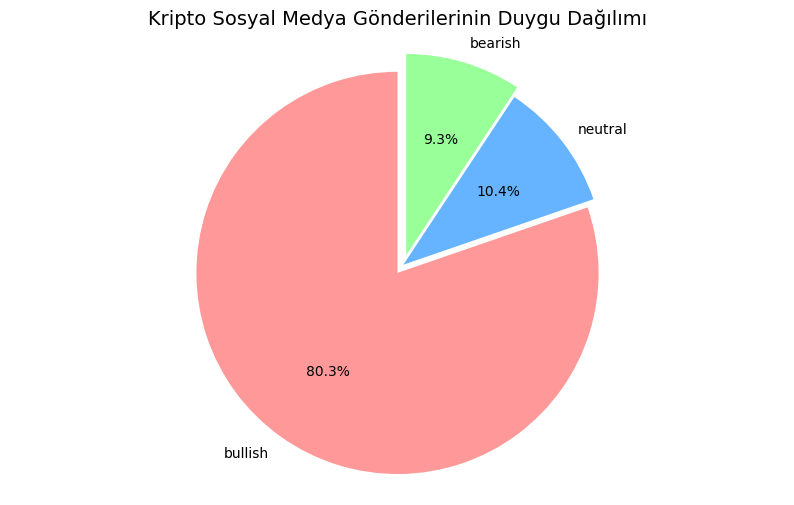

C:\Users\srb\AppData\Local\Temp\ipykernel_22996\2660002359.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)


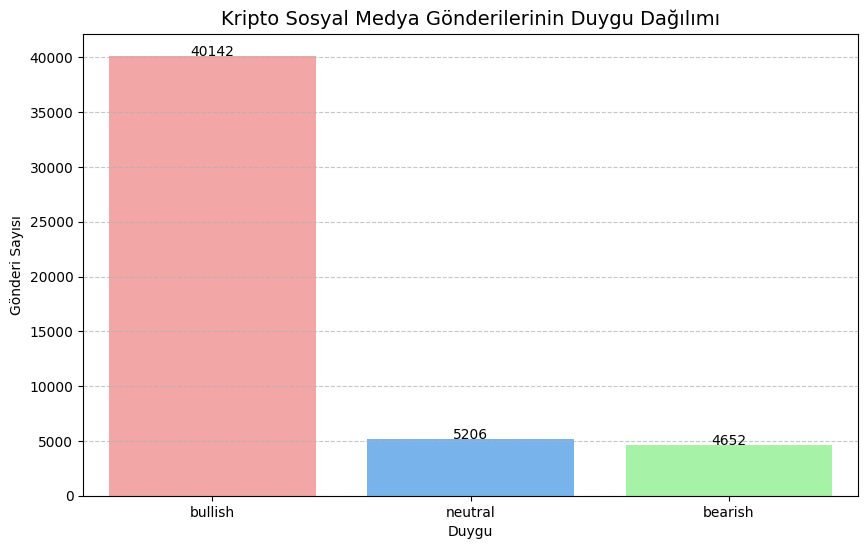

In [19]:
# Sonuçları kaydetme
sentiment_output_path = os.path.join(output_dir, 'sentiment_crypto_data.csv')
df.to_csv(sentiment_output_path, index=False)
print(f"\nDuygu analizi sonuçları şu konuma kaydedildi: {sentiment_output_path}")

# Duygu dağılımını görselleştirme - Pasta Grafiği
plt.figure(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']  # bearish, neutral, bullish renkleri
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=[0.05, 0, 0.05])
plt.title('Kripto Sosyal Medya Gönderilerinin Duygu Dağılımı', fontsize=14)
plt.axis('equal')  # Dairesel görünüm için

# Grafiği kaydet ve göster
pie_chart_path = os.path.join(output_dir, 'sentiment_distribution_pie.png')
plt.savefig(pie_chart_path)
plt.show()

# Duygu dağılımını görselleştirme - Çubuk Grafiği
plt.figure(figsize=(10, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)
plt.title('Kripto Sosyal Medya Gönderilerinin Duygu Dağılımı', fontsize=14)
plt.xlabel('Duygu')
plt.ylabel('Gönderi Sayısı')
plt.xticks(rotation=0)  # Etiketleri düz göster
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Çubukların üzerine değerleri yazma
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center')

# Grafiği kaydet ve göster
bar_chart_path = os.path.join(output_dir, 'sentiment_distribution_bar.png')
plt.savefig(bar_chart_path)
plt.show()

### Adım 14: Zamanla Değişen Duygu Analizi
Bu kod bloğu:

- Günlük duygu dağılımını hesaplar ve stacked area chart olarak görselleştirir
- Aylık duygu dağılımını hesaplar ve stacked bar chart olarak görselleştirir
- Zaman içinde duygu değişimlerini gösterir, böylece kripto pazarındaki duygu dalgalanmalarını zaman bazında analiz edebiliriz

<Figure size 1600x800 with 0 Axes>

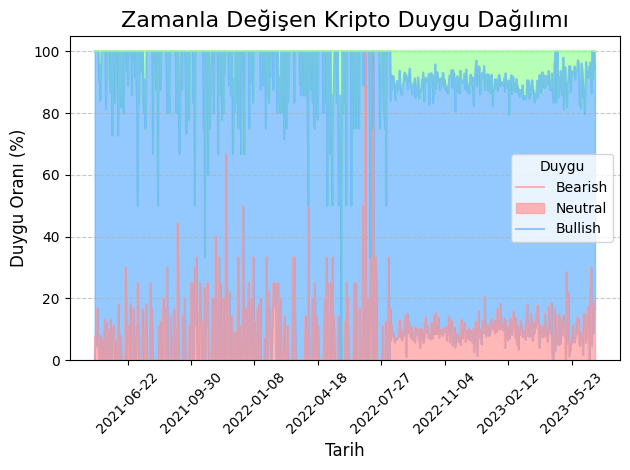

<Figure size 1400x800 with 0 Axes>

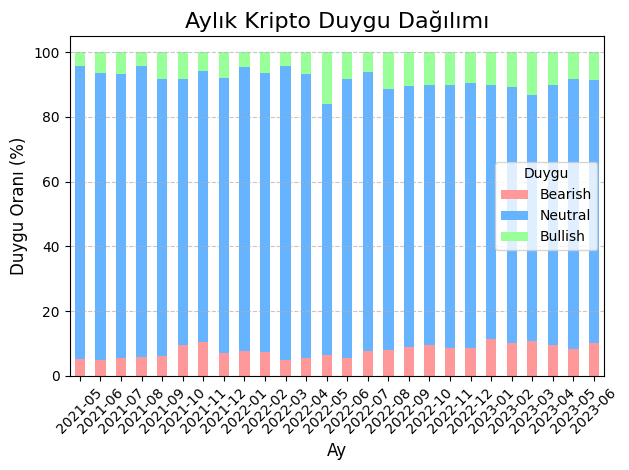

In [20]:
# Zamanla değişen duygu analizi - Günlük duygu dağılımı
# Tarih alanını oluştur
df['date'] = df['created_at'].dt.date

# Günlük duygu dağılımını hesapla
daily_sentiment = df.groupby(['date', 'sentiment']).size().unstack(fill_value=0)

# Duygu oranlarını hesapla
daily_sentiment_pct = daily_sentiment.div(daily_sentiment.sum(axis=1), axis=0) * 100

# Zaman serisi grafiği çiz
plt.figure(figsize=(16, 8))
daily_sentiment_pct.plot(kind='area', stacked=True, color=colors, alpha=0.7)
plt.title('Zamanla Değişen Kripto Duygu Dağılımı', fontsize=16)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Duygu Oranı (%)', fontsize=12)
plt.legend(title='Duygu', labels=['Bearish', 'Neutral', 'Bullish'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# X eksenindeki tarihleri düzenle (çok yoğun olmaması için)
from matplotlib.ticker import MaxNLocator
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(10))  # X ekseninde maksimum 10 tarih göster

# Grafiği kaydet ve göster
time_series_path = os.path.join(output_dir, 'sentiment_over_time.png')
plt.tight_layout()  # Grafiğin sınırlara taşmaması için
plt.savefig(time_series_path)
plt.show()

# Aylık duygu dağılımı analizi
df['month_year'] = df['created_at'].dt.to_period('M')
monthly_sentiment = df.groupby(['month_year', 'sentiment']).size().unstack(fill_value=0)
monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 8))
monthly_sentiment_pct.plot(kind='bar', stacked=True, color=colors)
plt.title('Aylık Kripto Duygu Dağılımı', fontsize=16)
plt.xlabel('Ay', fontsize=12)
plt.ylabel('Duygu Oranı (%)', fontsize=12)
plt.legend(title='Duygu', labels=['Bearish', 'Neutral', 'Bullish'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Grafiği kaydet ve göster
monthly_chart_path = os.path.join(output_dir, 'monthly_sentiment.png')
plt.tight_layout()
plt.savefig(monthly_chart_path)
plt.show()

### Adım 15: Kaynaklara Göre Duygu Analizi
Bu kod bloğu:

- Twitter ve Reddit platformlarına göre duygu dağılımını hesaplar
- Platformlar arası duygu farklılıklarını stacked bar chart olarak görselleştirir
- Her platform için detaylı duygu dağılımını yüzde ve sayı olarak gösterir

<Figure size 1200x600 with 0 Axes>

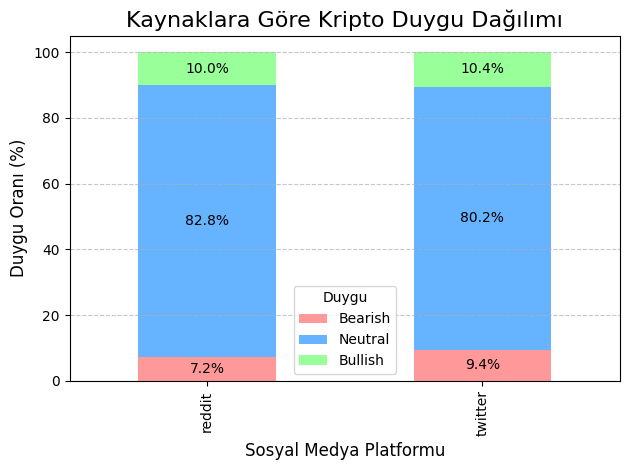


Platformlara Göre Duygu Dağılımı:

REDDIT:
  bearish: 178 gönderi (7.20%)
  bullish: 2046 gönderi (82.80%)
  neutral: 247 gönderi (10.00%)

TWITTER:
  bearish: 4474 gönderi (9.41%)
  bullish: 38096 gönderi (80.15%)
  neutral: 4959 gönderi (10.43%)


In [21]:
# Kaynaklara göre (Twitter vs Reddit) duygu analizi
source_sentiment = df.groupby(['source', 'sentiment']).size().unstack(fill_value=0)
source_sentiment_pct = source_sentiment.div(source_sentiment.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
source_sentiment_pct.plot(kind='bar', stacked=True, color=colors)
plt.title('Kaynaklara Göre Kripto Duygu Dağılımı', fontsize=16)
plt.xlabel('Sosyal Medya Platformu', fontsize=12)
plt.ylabel('Duygu Oranı (%)', fontsize=12)
plt.legend(title='Duygu', labels=['Bearish', 'Neutral', 'Bullish'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Platformlara göre değerleri ekle
for i, source in enumerate(source_sentiment_pct.index):
    for j, col in enumerate(source_sentiment_pct.columns):
        value = source_sentiment_pct.iloc[i, j]
        if value > 5:  # Sadece %5'ten büyük değerleri göster
            plt.text(i, source_sentiment_pct.iloc[i, :j].sum() + value/2, 
                     f"{value:.1f}%", ha='center', va='center')

# Grafiği kaydet ve göster
source_chart_path = os.path.join(output_dir, 'sentiment_by_source.png')
plt.tight_layout()
plt.savefig(source_chart_path)
plt.show()

# Her bir kaynak için duygu sayılarını ve yüzdelerini göster
print("\nPlatformlara Göre Duygu Dağılımı:")
for source in source_sentiment.index:
    print(f"\n{source.upper()}:")
    total = source_sentiment.loc[source].sum()
    for sentiment in source_sentiment.columns:
        count = source_sentiment.loc[source, sentiment]
        percentage = (count / total) * 100
        print(f"  {sentiment}: {count} gönderi ({percentage:.2f}%)")

### Adım 16: Haftalık ve Saatlik Duygu Analizi
Bu kod bloğu:

- Haftanın günlerine göre duygu dağılımını hesaplar ve görselleştirir
- Günün saatlerine göre duygu dağılımını hesaplar ve görselleştirir
- Hafta içi/hafta sonu ve günün farklı saatlerindeki duygu farklılıklarını analiz etmemizi sağlar

<Figure size 1400x600 with 0 Axes>

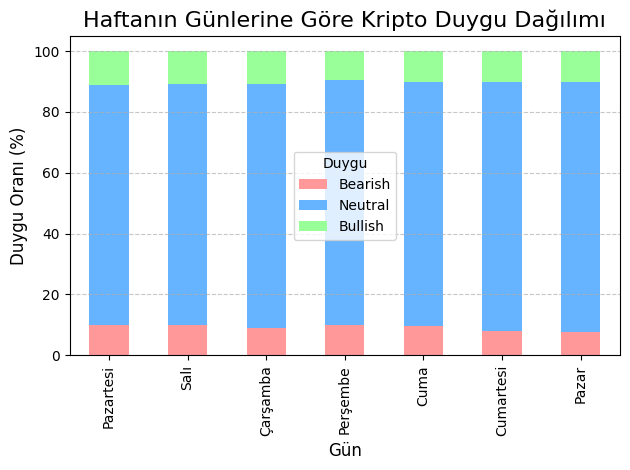

<Figure size 1600x600 with 0 Axes>

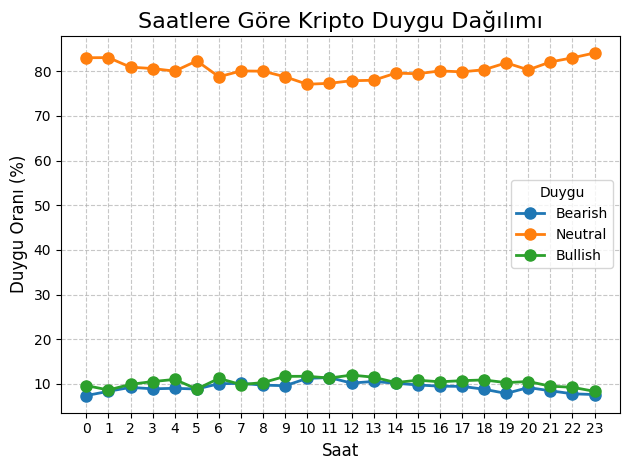

In [22]:
# Haftanın günlerine göre duygu analizi
if 'weekday' not in df.columns:
    df['weekday'] = df['created_at'].dt.dayofweek
    
weekday_names = {0:'Pazartesi', 1:'Salı', 2:'Çarşamba', 3:'Perşembe', 
                 4:'Cuma', 5:'Cumartesi', 6:'Pazar'}
df['weekday_name'] = df['weekday'].map(weekday_names)

weekday_sentiment = df.groupby(['weekday_name', 'sentiment']).size().unstack(fill_value=0)
weekday_order = ['Pazartesi', 'Salı', 'Çarşamba', 'Perşembe', 'Cuma', 'Cumartesi', 'Pazar']
weekday_sentiment = weekday_sentiment.reindex(weekday_order)
weekday_sentiment_pct = weekday_sentiment.div(weekday_sentiment.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 6))
weekday_sentiment_pct.plot(kind='bar', stacked=True, color=colors)
plt.title('Haftanın Günlerine Göre Kripto Duygu Dağılımı', fontsize=16)
plt.xlabel('Gün', fontsize=12)
plt.ylabel('Duygu Oranı (%)', fontsize=12)
plt.legend(title='Duygu', labels=['Bearish', 'Neutral', 'Bullish'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafiği kaydet ve göster
weekday_chart_path = os.path.join(output_dir, 'sentiment_by_weekday.png')
plt.tight_layout()
plt.savefig(weekday_chart_path)
plt.show()

# Saatlik duygu analizi
if 'hour' not in df.columns:
    df['hour'] = df['created_at'].dt.hour
    
hourly_sentiment = df.groupby(['hour', 'sentiment']).size().unstack(fill_value=0)
hourly_sentiment_pct = hourly_sentiment.div(hourly_sentiment.sum(axis=1), axis=0) * 100

plt.figure(figsize=(16, 6))
hourly_sentiment_pct.plot(kind='line', marker='o', linewidth=2, markersize=8)
plt.title('Saatlere Göre Kripto Duygu Dağılımı', fontsize=16)
plt.xlabel('Saat', fontsize=12)
plt.ylabel('Duygu Oranı (%)', fontsize=12)
plt.legend(title='Duygu', labels=['Bearish', 'Neutral', 'Bullish'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(0, 24))

# Grafiği kaydet ve göster
hourly_chart_path = os.path.join(output_dir, 'sentiment_by_hour.png')
plt.tight_layout()
plt.savefig(hourly_chart_path)
plt.show()

### Adım 17: Duygu Analizi Özet Raporu
Bu kod bloğu:

- Tüm analizlerin özetini bir rapor halinde gösterir
- Genel duygu dağılımı, platformlara göre, aylara göre ve haftanın günlerine göre duygu dağılımlarını tablo olarak gösterir
- Kaydedilen tüm dosyaların konumlarını listeler
- Duygu analizi sürecinin tamamlandığını bildirir

In [23]:
# Duygu analizinin özet raporu
print("\n===== DUYGU ANALİZİ ÖZET RAPOR =====")
print(f"Toplam analiz edilen gönderi sayısı: {len(df)}")
print("\nGenel Duygu Dağılımı:")
for sentiment, count in sentiment_counts.items():
    print(f"{sentiment}: {count} gönderi ({count/len(df)*100:.2f}%)")

print("\nPlatformlara Göre Duygu Dağılımı:")
print(source_sentiment_pct.round(2))

print("\nAylık Duygu Dağılımı (%):")
print(monthly_sentiment_pct.round(2))

print("\nHaftanın Günlerine Göre Duygu Dağılımı (%):")
print(weekday_sentiment_pct.round(2))

# Tüm grafiklerin ve analiz sonuçlarının kaydedildiği konumları göster
print("\nKaydedilen Dosyalar:")
print(f"1. Duygu analizi CSV: {sentiment_output_path}")
print(f"2. Genel duygu dağılımı (pasta): {pie_chart_path}")
print(f"3. Genel duygu dağılımı (çubuk): {bar_chart_path}")
print(f"4. Zamanla değişen duygu: {time_series_path}")
print(f"5. Aylık duygu analizi: {monthly_chart_path}")
print(f"6. Platformlara göre duygu: {source_chart_path}")
print(f"7. Günlere göre duygu: {weekday_chart_path}")
print(f"8. Saatlere göre duygu: {hourly_chart_path}")

print("\nDuygu analizi süreci tamamlandı!")


===== DUYGU ANALİZİ ÖZET RAPOR =====
Toplam analiz edilen gönderi sayısı: 50000

Genel Duygu Dağılımı:
bullish: 40142 gönderi (80.28%)
neutral: 5206 gönderi (10.41%)
bearish: 4652 gönderi (9.30%)

Platformlara Göre Duygu Dağılımı:
sentiment  bearish  bullish  neutral
source                              
reddit        7.20    82.80    10.00
twitter       9.41    80.15    10.43

Aylık Duygu Dağılımı (%):
sentiment   bearish  bullish  neutral
month_year                           
2021-05        5.10    90.45     4.46
2021-06        4.94    88.59     6.46
2021-07        5.41    87.84     6.76
2021-08        5.79    90.00     4.21
2021-09        6.21    85.31     8.47
2021-10        9.66    82.13     8.21
2021-11       10.53    83.63     5.85
2021-12        6.98    84.88     8.14
2022-01        7.76    87.67     4.57
2022-02        7.35    86.27     6.37
2022-03        4.86    90.81     4.32
2022-04        5.41    87.84     6.76
2022-05        6.62    77.48    15.89
2022-06        5.63    